In [41]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Fragments
import matplotlib.pyplot as plt
from collections import Counter
import seaborn
from tqdm import tqdm

In [9]:
#data
data_path = '../../data/dataset/285k_train_15k_val_test_1024bits_df.gz'
dataset_df = pd.read_pickle(data_path)
dataset_df.columns

Index(['path', 'CID', 'SMILES', 'morgan_fp', 'split', 'corrugation'], dtype='object')

In [10]:
train_df = dataset_df[dataset_df['split']=='train'] 
train_df['Mol'] = train_df['SMILES'].apply(Chem.MolFromSmiles)
train_df = train_df[train_df['Mol'].notnull()]

train_df

[11:26:13] WARNING: could not find number of expected rings. Switching to an approximate ring finding algorithm.
/tmp/ipykernel_316619/3896047379.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['Mol'] = train_df['SMILES'].apply(Chem.MolFromSmiles)


,path,CID,SMILES,morgan_fp,split,corrugation,Mol
0,/scratch/dataset/quam/K-1/Conformer3D_CID_1000...,10000010,C1=CC=C(C=C1)C2=CC3=CC(=NC=C3O2)C(=O)NC4=C(C=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,1.1083,<rdkit.Chem.rdchem.Mol object at 0x7f17ad7bbd80>
2,/scratch/dataset/quam/K-1/Conformer3D_CID_1000...,10001815,C1=C(C2=NO[N+](=C2C3=C1N4N=C5C(=[N+]4[N-]3)C=C...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,0.0069,<rdkit.Chem.rdchem.Mol object at 0x7f17ad7bbf40>
3,/scratch/dataset/quam/K-1/Conformer3D_CID_1000...,100027166,CC1=CN(N=C1OCCCC(=O)O)C2=CC=CC=C2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...",train,0.1112,<rdkit.Chem.rdchem.Mol object at 0x7f17ad7bbae0>
4,/scratch/dataset/quam/K-1/Conformer3D_CID_1000...,100027208,CC1=C(N=CC=C1)NC(=O)CCCN,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,0.0402,<rdkit.Chem.rdchem.Mol object at 0x7f17ad7bba70>
5,/scratch/dataset/quam/K-1/Conformer3D_CID_1000...,100029155,CC1=C(C2=C(N1)C3=C(C=CC=N3)C=C2)C(=O)O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,0.0011,<rdkit.Chem.rdchem.Mol object at 0x7f17ad7bba00>
...,...,...,...,...,...,...,...
579895,/scratch/dataset/quam/K-1/Conformer3D_CID_1370...,137045744,CC1=NC(=CC=C1)C2=NC(=CC(=O)N2)C(=O)O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,0.0207,<rdkit.Chem.rdchem.Mol object at 0x7f17934c1fc0>
579896,/scratch/dataset/quam/K-1/Conformer3D_CID_1371...,1371975,C1=CC=C2C(=C1)C=C(O2)C(=O)NC3=CC=C(C=C3)C4=NC5...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,0.1017,<rdkit.Chem.rdchem.Mol object at 0x7f17934c1f50>
579898,/scratch/dataset/quam/K-1/Conformer3D_CID_2779...,2779733,COC(=O)C1=CC2=C(C=C1)N=CN2,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,0.8636,<rdkit.Chem.rdchem.Mol object at 0x7f17934c1ee0>
579899,/scratch/dataset/quam/K-1/Conformer3D_CID_3035...,303539,C1=CC=C2C(=C1)NC(=N2)SCCSC3=NC4=CC=CC=C4N3,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",train,0.0072,<rdkit.Chem.rdchem.Mol object at 0x7f17934c1e70>


In [11]:
# Functional groups in rdkit fragments
fg_functions = {name: getattr(Fragments, name) for name in dir(Fragments) if name.startswith('fr_')}
print(fg_functions)

{'fr_Al_COO': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad703eb0>, 'fr_Al_OH': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad703be0>, 'fr_Al_OH_noTert': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad7b25f0>, 'fr_ArN': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad7b2b00>, 'fr_Ar_COO': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad703f40>, 'fr_Ar_N': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad7b05e0>, 'fr_Ar_NH': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad7b0670>, 'fr_Ar_OH': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad703c70>, 'fr_COO': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad7b0040>, 'fr_COO2': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad7b00d0>, 'fr_C_O': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad703ac0>, 'fr_C_O_noCOO': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad703b50>, 'fr_C_S': <function _LoadPatterns.<locals>.<lambda> at 0x7f17ad7b1480>, 'fr_HOCCN': <function _LoadPattern

In [16]:
fg_counts = Counter()

for mol in train_df['Mol']:
    for fg_name, fg_func in fg_functions.items():
        count = fg_func(mol)
        if count > 0:
            fg_counts[fg_name] += count

# Convert the counts to a DataFrame for easier manipulation
fg_df = pd.DataFrame({'fr_names': fg_counts.keys(), 
                      'Count': fg_counts.values()})
fg_df.sort_values('Count', ascending=False, inplace=True)

fg_df

,fr_names,Count
6,fr_NH0,460326
1,fr_Ar_N,445984
10,fr_benzene,260273
76,fr_halogen,231347
7,fr_NH1,208057
...,...,...
71,fr_epoxide,29
70,fr_quatN,13
73,fr_morpholine,9
75,fr_piperzine,6


In [17]:
fg_df.head(20)

,fr_names,Count
6,fr_NH0,460326
1,fr_Ar_N,445984
10,fr_benzene,260273
76,fr_halogen,231347
7,fr_NH1,208057
11,fr_bicyclic,203022
9,fr_aniline,188460
4,fr_C_O,187838
5,fr_C_O_noCOO,157710
8,fr_amide,114299


In [28]:
# Map top 20 functional groups names to something legible. 
# They are listed here https://rdkit.org/docs/source/rdkit.Chem.Fragments.html
fg_name_mapping = {
    'fr_NH0': 'Tertiary amines',
    'fr_Ar_N': 'Aromatic nitrogens',
    'fr_benzene': 'Benzene rings',
    'fr_halogen': 'Halogens',
    'fr_NH1': 'Secondary amines',
    'fr_bicyclic': 'Bicyclic ring system',
    'fr_aniline': 'Anilines',
    'fr_C_O': 'Carbonyl groups (C=O)',
    'fr_C_O_noCOO': 'Carbonyl groups (non-carboxyl, COOH)',
    'fr_amide': 'Amides',
    'fr_aryl_methyl': 'Aryl methyls ',
    'fr_pyridine': 'Pyridine rings',
    'fr_NH2': 'Primary amines',
    'fr_Nhpyrrole': 'H-pyrrole nitrogens',
    'fr_Ar_NH': 'Aromatic amines',
    'fr_ether': 'Ether oxygens (including phenoxy)',
    'fr_ArN': 'Aromatic nitrogen-containing groups',
    'fr_para_hydroxylation': 'Para hydroxylation sites',
    'fr_methoxy': 'methoxy groups (-OCH3)',
    'fr_Ar_OH': 'Aromatic hydroxyls',
}

fg_df_renamed = fg_df.iloc[:20].copy()
# Apply the mapping to the DataFrame
fg_df_renamed.reset_index(inplace=True)
fg_df_renamed['Functional_Group'] = fg_df_renamed['fr_names'].map(fg_name_mapping)
fg_df_renamed.drop(columns=['index', 'fr_names'], inplace=True)

fg_df_renamed

,Count,Functional_Group
0,460326,Tertiary amines
1,445984,Aromatic nitrogens
2,260273,Benzene rings
3,231347,Halogens
4,208057,Secondary amines
5,203022,Bicyclic ring system
6,188460,Anilines
7,187838,Carbonyl groups (C=O)
8,157710,"Carbonyl groups (non-carboxyl, COOH)"
9,114299,Amides


/tmp/ipykernel_316619/3233548007.py:20: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "quality" which is no longer supported as of 3.3 and will become an error in 3.6
  plt.savefig('Functional_group_training_set.pdf', dpi=500, format='pdf', quality=120, optimize=True)
/tmp/ipykernel_316619/3233548007.py:20: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "optimize" which is no longer supported as of 3.3 and will become an error in 3.6
  plt.savefig('Functional_group_training_set.pdf', dpi=500, format='pdf', quality=120, optimize=True)


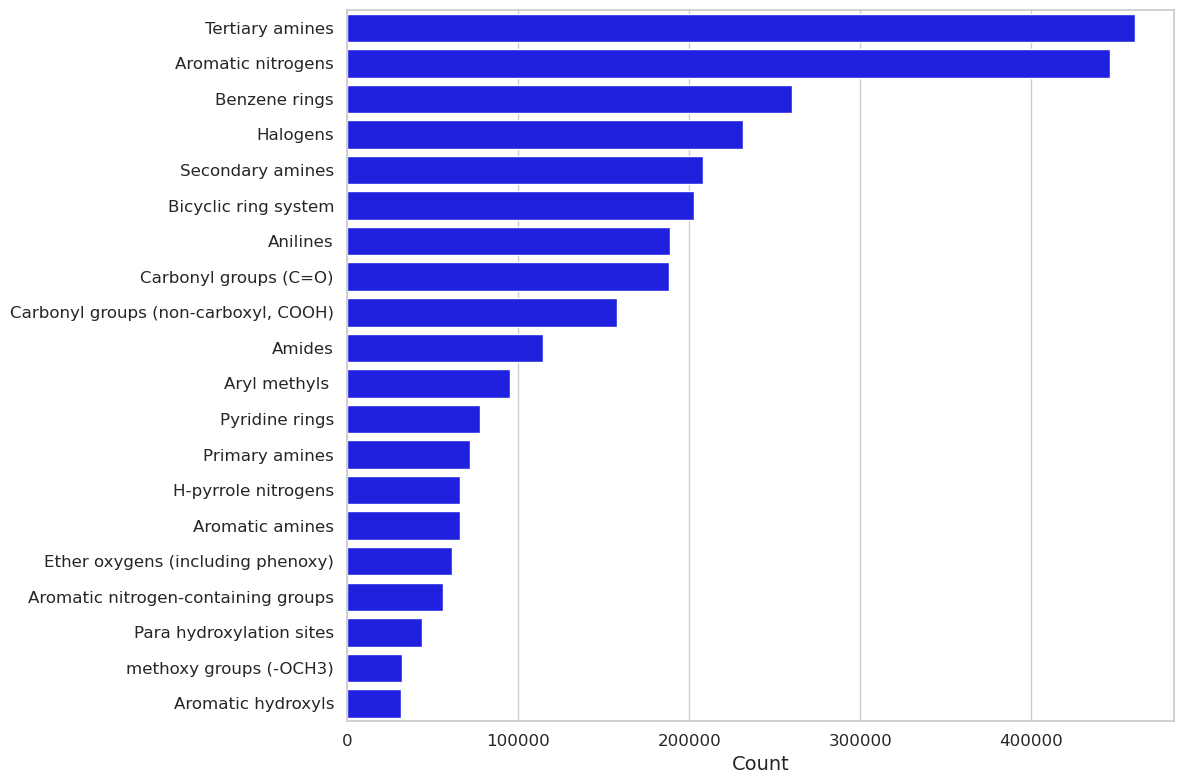

In [36]:
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

ax = sns.barplot(x='Count', y='Functional_Group', data=fg_df_renamed, color='blue')

ax.set_xlabel('Count', fontsize=14)
ax.set_ylabel('', fontsize=14)

ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()

plt.savefig('Functional_group_training_set.pdf', dpi=500, format='pdf', quality=120, optimize=True)
plt.show()

In [40]:
def extract_functional_groups(split_df):
    
    smiles_df = split_df.copy()
    smiles_df['Mol'] = smiles_df['SMILES'].apply(Chem.MolFromSmiles)
    smiles_df = smiles_df[smiles_df['Mol'].notnull()]
    
    fg_functions = {name: getattr(Fragments, name) for name in dir(Fragments) if name.startswith('fr_')}
    fg_counts = Counter()

    for mol in smiles_df['Mol']:
        for fg_name, fg_func in fg_functions.items():
            count = fg_func(mol)
            if count > 0:
                fg_counts[fg_name] += count

   
    fg_df = pd.DataFrame({'fr_names': fg_counts.keys(), 
                          'Count': fg_counts.values()})
    fg_df.sort_values('Count', ascending=False, inplace=True)

    fg_df_renamed = fg_df.iloc[:20].copy()
    
    return fg_df_renamed
        

In [50]:
fg_groups_split = dict()
for split in tqdm(dataset_df['split'].unique()):
    split_df = dataset_df[dataset_df['split'] == split]
    fg_groups_split[split] = extract_functional_groups(split_df)

fg_groups_split

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [04:19<00:00, 86.48s/it]


{'train':                  fr_names   Count
 6                  fr_NH0  460326
 1                 fr_Ar_N  445984
 10             fr_benzene  260273
 76             fr_halogen  231347
 7                  fr_NH1  208057
 11            fr_bicyclic  203022
 9              fr_aniline  188460
 4                  fr_C_O  187838
 5            fr_C_O_noCOO  157710
 8                fr_amide  114299
 19         fr_aryl_methyl   95283
 14            fr_pyridine   77674
 23                 fr_NH2   71632
 25           fr_Nhpyrrole   66192
 24               fr_Ar_NH   66192
 20               fr_ether   61368
 27                 fr_ArN   55765
 21  fr_para_hydroxylation   43916
 35             fr_methoxy   31813
 34               fr_Ar_OH   31197,
 'test':                  fr_names   Count
 2                  fr_NH0  452229
 0                 fr_Ar_N  438375
 5              fr_benzene  255002
 76             fr_halogen  227906
 3                  fr_NH1  203168
 6             fr_bicyclic  198456
 1

In [51]:
fg_name_mapping = {
    'fr_NH0': 'Tertiary amines',
    'fr_Ar_N': 'Aromatic nitrogens',
    'fr_benzene': 'Benzene rings',
    'fr_halogen': 'Halogens',
    'fr_NH1': 'Secondary amines',
    'fr_bicyclic': 'Bicyclic ring system',
    'fr_aniline': 'Anilines',
    'fr_C_O': 'Carbonyl groups (C=O)',
    'fr_C_O_noCOO': 'Carbonyl groups (non-carboxyl, COOH)',
    'fr_amide': 'Amides',
    'fr_aryl_methyl': 'Aryl methyls ',
    'fr_pyridine': 'Pyridine rings',
    'fr_NH2': 'Primary amines',
    'fr_Nhpyrrole': 'H-pyrrole nitrogens',
    'fr_Ar_NH': 'Aromatic amines',
    'fr_ether': 'Ether oxygens (including phenoxy)',
    'fr_ArN': 'Aromatic nitrogen-containing groups',
    'fr_para_hydroxylation': 'Para hydroxylation sites',
    'fr_methoxy': 'methoxy groups (-OCH3)',
    'fr_Ar_OH': 'Aromatic hydroxyls',
}

for fg_df in fg_groups_split.values():
    
    fg_df.reset_index(inplace=True)
    fg_df['Functional_Group'] = fg_df['fr_names'].map(fg_name_mapping)
    fg_df.drop(columns=['index', 'fr_names'], inplace=True)

fg_groups_split

{'train':      Count                      Functional_Group
 0   460326                       Tertiary amines
 1   445984                    Aromatic nitrogens
 2   260273                         Benzene rings
 3   231347                              Halogens
 4   208057                      Secondary amines
 5   203022                  Bicyclic ring system
 6   188460                              Anilines
 7   187838                 Carbonyl groups (C=O)
 8   157710  Carbonyl groups (non-carboxyl, COOH)
 9   114299                                Amides
 10   95283                         Aryl methyls 
 11   77674                        Pyridine rings
 12   71632                        Primary amines
 13   66192                   H-pyrrole nitrogens
 14   66192                       Aromatic amines
 15   61368     Ether oxygens (including phenoxy)
 16   55765   Aromatic nitrogen-containing groups
 17   43916              Para hydroxylation sites
 18   31813                methoxy groups

/tmp/ipykernel_316619/2514299224.py:29: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "quality" which is no longer supported as of 3.3 and will become an error in 3.6
  plt.savefig('Functional_group_training_test_val_set.pdf', dpi=500, format='pdf', quality=120, optimize=True)
/tmp/ipykernel_316619/2514299224.py:29: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "optimize" which is no longer supported as of 3.3 and will become an error in 3.6
  plt.savefig('Functional_group_training_test_val_set.pdf', dpi=500, format='pdf', quality=120, optimize=True)


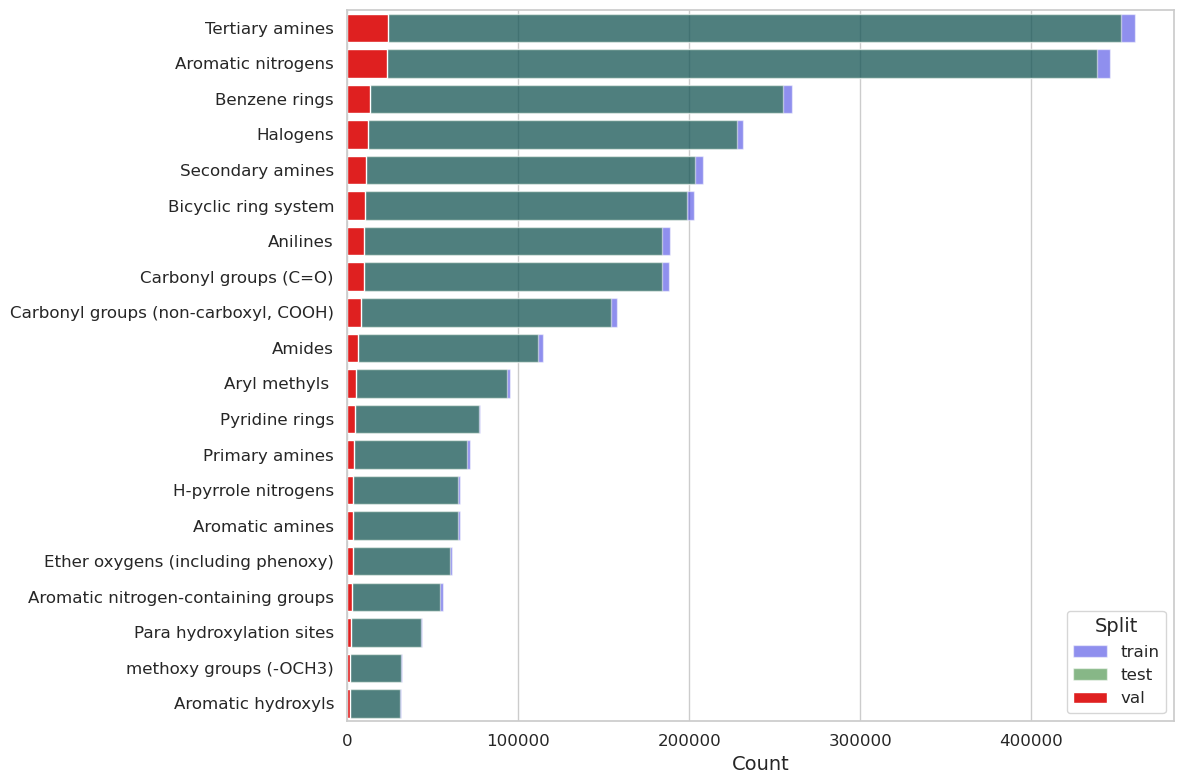

In [56]:
# Set the figure size and plot style
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Define a color map for each split
colors = {'train': 'blue', 'test': 'green', 'val': 'red'}
alphas = {'train': 0.5, 'test': 0.5, 'val': 1}
# Iterate over the splits and plot each one
for split, color in colors.items():
    # Get the dataframe for the current split
    df = fg_groups_split[split].copy()
    
    # Plot the barplot for the current split
    sns.barplot(x='Count', y='Functional_Group', data=df, color=color, label=split, alpha =alphas[split])

# Set axis labels and adjust the size of the ticks and labels
plt.xlabel('Count', fontsize=14)
plt.ylabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a legend to differentiate between 'train', 'test', and 'val'
plt.legend(title='Split', fontsize=12, title_fontsize=14)

# Add tight layout for better spacing
plt.tight_layout()

# Save the plot
plt.savefig('Functional_group_training_test_val_set.pdf', dpi=500, format='pdf', quality=120, optimize=True)

# Show the plot
plt.show()

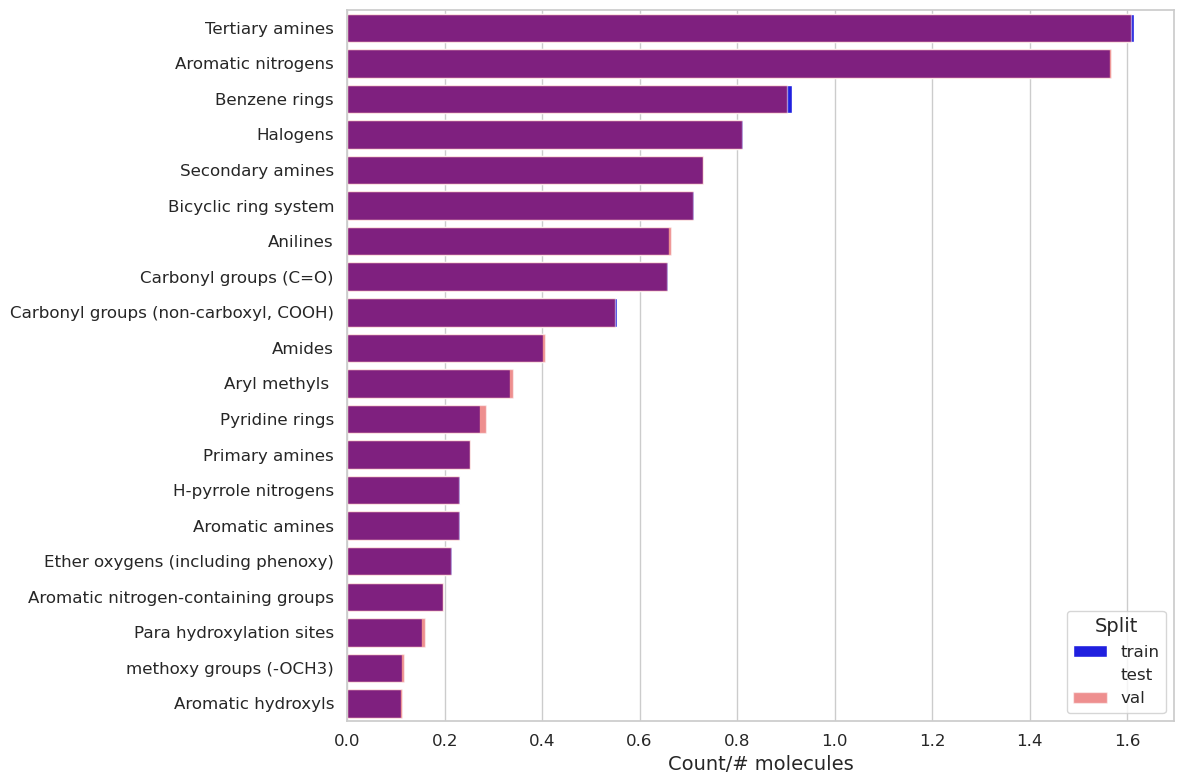

In [61]:
fg_groups_split_norm = dict()

for split, df in fg_groups_split.items():
    df_norm = df.copy()
    df_norm['Count_norm'] = df_norm['Count']/len(dataset_df[dataset_df['split']==split])
    fg_groups_split_norm[split] = df_norm

# Set the figure size and plot style
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Define a color map for each split
colors = {'train': 'blue', 'test': 'green', 'val': 'red'}
# Iterate over the splits and plot each one
for split, color in colors.items():
    # Get the dataframe for the current split
    df = fg_groups_split_norm[split].copy()
    
    # Plot the barplot for the current split
    sns.barplot(x='Count_norm', y='Functional_Group', data=df, color=color, label=split, alpha =alphas[split])

# Set axis labels and adjust the size of the ticks and labels
plt.xlabel('Count/# molecules', fontsize=14)
plt.ylabel('', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Add a legend to differentiate between 'train', 'test', and 'val'
plt.legend(title='Split', fontsize=12, title_fontsize=14)

# Add tight layout for better spacing
plt.tight_layout()

# Save the plot
#plt.savefig('Functional_group_training_test_val_set.pdf', dpi=500, format='pdf', quality=120, optimize=True)

# Show the plot
plt.show()

/tmp/ipykernel_316619/1195346546.py:51: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "quality" which is no longer supported as of 3.3 and will become an error in 3.6
  plt.savefig('Functional_group_proportions_by_split.pdf', dpi=500, format='pdf', quality=120, optimize=True)
/tmp/ipykernel_316619/1195346546.py:51: MatplotlibDeprecationWarning: savefig() got unexpected keyword argument "optimize" which is no longer supported as of 3.3 and will become an error in 3.6
  plt.savefig('Functional_group_proportions_by_split.pdf', dpi=500, format='pdf', quality=120, optimize=True)


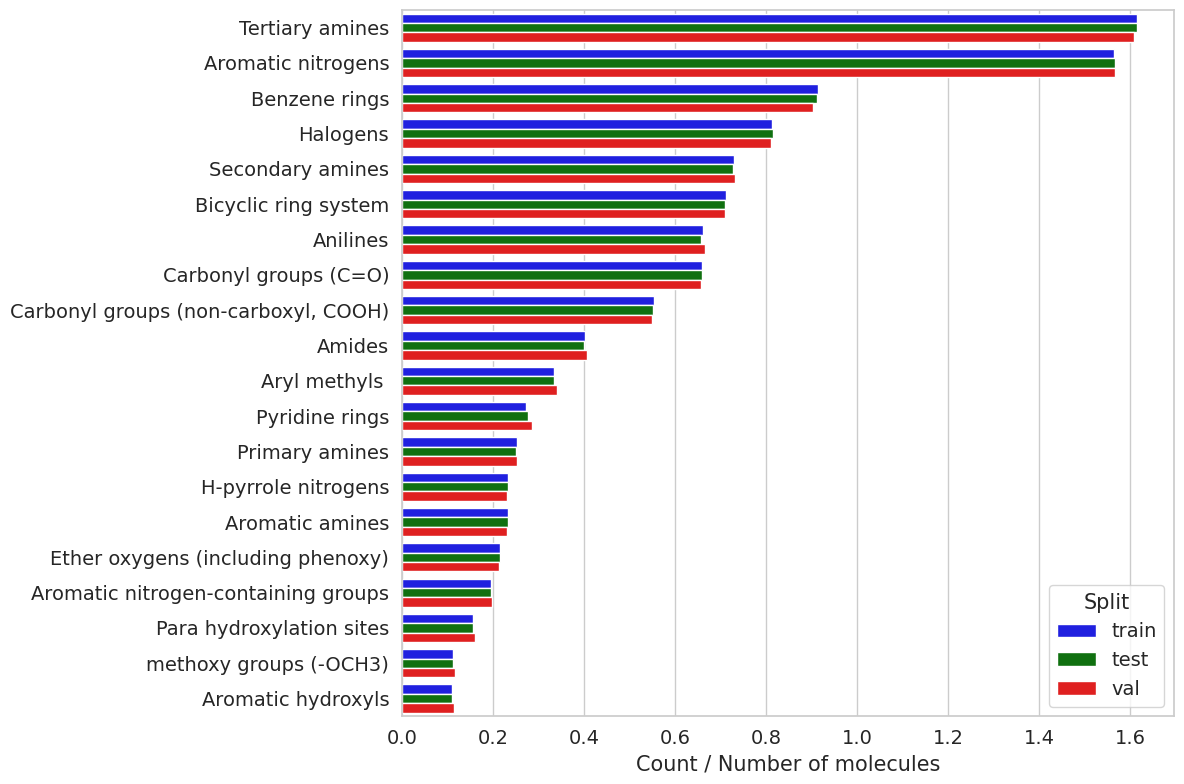

In [71]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume 'dataset_df' has a 'split' column indicating 'train', 'test', or 'val'
# And 'fg_groups_split' is a dictionary containing DataFrames for each split

# Step 1: Normalize the counts
fg_groups_split_norm = {}
for split, df in fg_groups_split.items():
    df_norm = df.copy()
    num_molecules = len(dataset_df[dataset_df['split'] == split])
    df_norm['Count_norm'] = df_norm['Count'] / num_molecules
    fg_groups_split_norm[split] = df_norm

# Step 2: Combine the normalized data into a single DataFrame
normalized_dfs = []
for split, df in fg_groups_split_norm.items():
    df_temp = df.copy()
    df_temp['Split'] = split  # Add a column to indicate the split
    normalized_dfs.append(df_temp[['Functional_Group', 'Count_norm', 'Split']])

combined_norm_df = pd.concat(normalized_dfs)

# Step 3: Plot the grouped bar chart
plt.figure(figsize=(12, 8))
sns.set(style="whitegrid")

# Create a grouped barplot
ax = sns.barplot(
    x='Count_norm',
    y='Functional_Group',
    hue='Split',
    data=combined_norm_df,
    palette={'train': 'blue', 'test': 'green', 'val': 'red'}
)

# Set axis labels and adjust the size of the ticks and labels
plt.xlabel('Count / Number of molecules', fontsize=15)
plt.ylabel('', fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

# Add a legend to differentiate between 'train', 'test', and 'val'
plt.legend(title='Split', fontsize=14, title_fontsize=15)

# Add tight layout for better spacing
plt.tight_layout()

# Save the plot
plt.savefig('Functional_group_proportions_by_split.pdf', dpi=500, format='pdf', quality=120, optimize=True)

# Show the plot
plt.show()


